# 7.4.1 局部线性化与扩展滤波

## 学习目标与先修知识

推导EKF并保留雅可比求值位置，解释局部近似失效。

先修：7.3的线性高斯滤波与第3篇偏导（partial derivative）、Jacobian和局部线性化（linearization）。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

某种仪器响应与状态（state）偏差的平方近似成正比。读数能提示变化幅度，却可能无法分辨正负。在线性滤波中仅替换函数名，为什么不能保证得到正确分布（distribution）？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
m=0.;P=1.;y=4.;R=.1;H=2*m
print('均值处观测导数=',H,'EKF增益=',P*H/(H*P*H+R))

均值处观测导数= 0.0 EKF增益= 0.0


## 模型假设

x为相对基线的有符号偏差U。教学转移 f(x)=x−Δr x/(1+|x|/s)，饱和尺度s=1 U，Δ=0.25步、r=0.6/步；这是带饱和回复的人工偏差模型（model），不是绝对所追踪物质总量（tracked amount）清除定律。过程噪声（process noise）方差（variance）Q=0.04 U²；平方观测（observation）y=x²+v，R=0.15 U⁴。噪声独立高斯。

## 数学解释与推导

扩展卡尔曼滤波（extended Kalman filtering，EKF）在可获得的均值处作一阶展开：
$$f(x)\approx f(m)+F_m(x-m),\quad m^-=f(m),\quad P^-=F_mPF_m^T+Q.$$
这里 $f'(m)=1-\Delta r/(1+|m|/s)^2$，其中s是与x同单位的饱和尺度。当前观测函数在预测均值处展开，$h(x)\approx h(m^-)+H_m(x-m^-)$。仍按条件Gaussian形式更新，但以
$$S=H_mP^-H_m^T+R,\quad C=P^-H_m^T,\quad K=CS^{-1}.$$
平方观测下 $h'(m^-)=2m^-$。若 $m^-=0$，EKF的C为0，因而完全不更新；真实观测仍约束 $|x|$。这指出一阶近似的范围：导数（derivative）小不表示观测没有统计信息。若f、h线性，展开精确，EKF退化为KF。

## 核心实现

下面按推导写出计算步骤；函数的输入（input）只包含模型与当时可用的信息。

In [3]:
def nonlinear_update(mean, variance, observation, measurement_variance, method='ekf'):
    if method == 'ekf':
        predicted_observation = mean ** 2
        cross = 2 * mean * variance
        innovation_variance = 4 * mean ** 2 * variance + measurement_variance
    elif method == 'ukf':
        # n=1, alpha=1,beta=2,kappa=0: Wm=(0,1/2,1/2), Wc=(2,1/2,1/2)。
        points = np.array([mean, mean + math.sqrt(variance), mean - math.sqrt(variance)])
        wm, wc = np.array([0., .5, .5]), np.array([2., .5, .5])
        transformed = points ** 2
        predicted_observation = float(wm @ transformed)
        cross = float(np.sum(wc * (points - mean) * (transformed - predicted_observation)))
        innovation_variance = float(np.sum(wc * (transformed - predicted_observation) ** 2) + measurement_variance)
    else:
        raise ValueError('method必须为ekf或ukf')
    gain = cross / innovation_variance
    return dict(mean=float(mean + gain * (observation - predicted_observation)),
                variance=float(variance - gain * cross), observation_mean=float(predicted_observation),
                innovation_variance=float(innovation_variance), cross_covariance=float(cross))


def saturating_step(state, step=.25, rate=.6, saturation_scale=1.0):
    """state和saturation_scale同为U；step*rate无量纲。"""
    return state - step * rate * state / (1 + np.abs(state) / saturation_scale)


def nonlinear_filter(initial_mean, initial_variance, process_variance, measurement_variance, observations, method):
    mean, variance = initial_mean, initial_variance
    saturation_scale = 1.0  # U，与状态单位相同。
    means, variances = [], []
    for t, observed in enumerate(observations):
        if t and method == 'ekf':
            derivative = 1 - .25 * .6 / (1 + abs(mean) / saturation_scale) ** 2
            mean, variance = saturating_step(mean, saturation_scale=saturation_scale), derivative ** 2 * variance + process_variance
        elif t:
            points = np.array([mean, mean + math.sqrt(variance), mean - math.sqrt(variance)])
            propagated = saturating_step(points, saturation_scale=saturation_scale)
            mean = float(np.array([0., .5, .5]) @ propagated)
            variance = float(np.array([2., .5, .5]) @ (propagated - mean) ** 2 + process_variance)
        if observed is not None:
            update = nonlinear_update(mean, variance, observed, measurement_variance, method)
            mean, variance = update['mean'], update['variance']
        means.append(float(mean)); variances.append(float(variance))
    return dict(means=means, variances=variances)


def grid_update(mean, variance, observation, measurement_variance, lower=-6, upper=6, count=6001):
    grid = np.linspace(lower, upper, count)
    log_mass = -.5 * ((grid - mean) ** 2 / variance + (observation - grid ** 2) ** 2 / measurement_variance)
    mass = np.exp(log_mass - log_mass.max())
    density = mass / np.trapezoid(mass, grid)
    updated_mean = float(np.trapezoid(grid * density, grid))
    updated_variance = float(np.trapezoid((grid - updated_mean) ** 2 * density, grid))
    return grid, density, updated_mean, updated_variance

## 对照实验

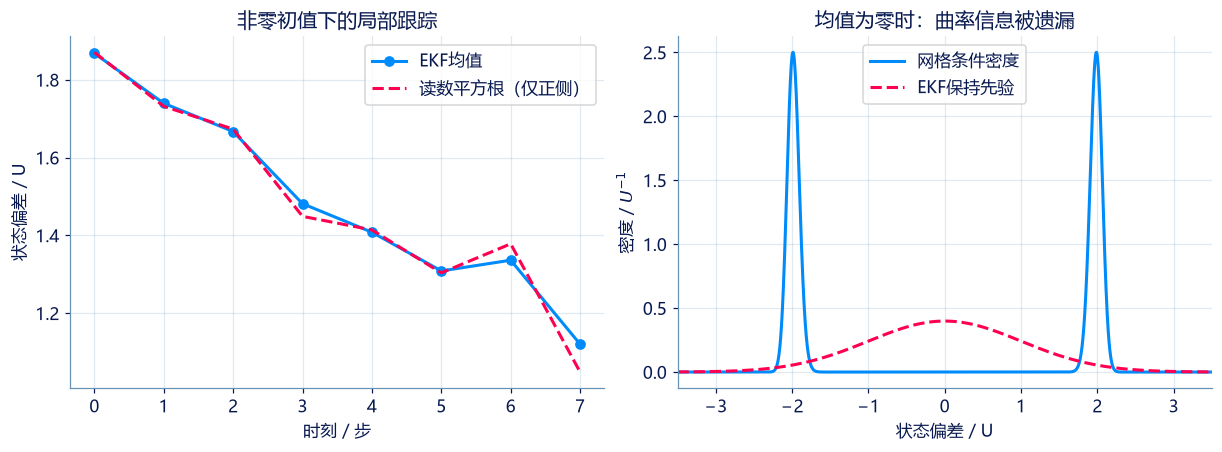

In [4]:
observed=[3.5,3.0,2.8,2.1,2.0,1.7,1.9,1.1]
run=nonlinear_filter(1.8,.2,.04,.15,observed,'ekf')
grid,density,true_mean,true_var=grid_update(0,1,4,.1,count=8001)
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(run['means'],'o-',label='EKF均值');axes[0].plot(np.sqrt(observed),'--',label='读数平方根（仅正侧）');axes[0].set(xlabel='时刻 / 步',ylabel='状态偏差 / U',title='非零初值下的局部跟踪');axes[0].legend()
axes[1].plot(grid,density,label='网格条件密度');axes[1].plot(grid,np.exp(-grid**2/2)/np.sqrt(2*np.pi),'--',label='EKF保持先验');axes[1].set(xlim=(-3.5,3.5),xlabel='状态偏差 / U',ylabel='密度 / $U^{-1}$',title='均值为零时：曲率信息被遗漏');axes[1].legend();plt.show()

### 独立核验与边界

In [5]:
unchanged=nonlinear_update(0,1,4,.1,'ekf');assert unchanged['mean']==0 and unchanged['variance']==1
assert abs(true_mean)<1e-10 and true_var>3
# 在线性退化h(x)=a*x+b下，逐项展开和条件高斯公式一致。
for a,b,m,P,R,y in [(2.,.3,1.,.4,.2,2.5),(-1.,0.,.2,1.,.1,-.4),(0.,2.,1.,.5,.3,3.)]:
    C=P*a;S=a*a*P+R;ekf_mean=m+C/S*(y-(a*m+b));ekf_var=P-C*C/S
    joint=np.array([[P,C],[C,S]])
    expected=m+joint[0,1]/joint[1,1]*(y-a*m-b)
    np.testing.assert_allclose(ekf_mean,expected);assert ekf_var>=0
print('零导数反例和线性退化条件核验通过。')

零导数反例和线性退化条件核验通过。


## 结果解释

左图的平方根只作直观参照，它强行选择正号，不能用来解决符号歧义。右图在对称条件下均值仍为0，但双峰和更大的方差说明分布发生了明显变化。把一个均值当作“真实状态”会掩盖这种不确定性。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：一次平方观测的扩展更新

先验（prior）x~N(mean,variance)，读数y=x²+v，v是与x独立的零均值高斯噪声，方差（variance）为measurement_variance。在先验均值处线性化（linearization），返回EKF更新后的均值和方差。

**函数与代码模板**

```python
def solve(
    mean: float,
    variance: float,
    observation: float,
    measurement_variance: float,
) -> tuple[float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean` | `float` | 先验均值。 | U |
| `variance` | `float` | 先验方差。 | U² |
| `observation` | `float` | 平方传感器的读数。 | U² |
| `measurement_variance` | `float` | 读数噪声方差。 | U⁴ |

**返回值**

按以下顺序返回元组：(updated_mean, updated_variance)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `updated_mean` | `float` | EKF近似后验（posterior）均值。 | U |
| `updated_variance` | `float` | EKF近似后验方差。 | U² |

**计算规则**

h(mean)=mean²，H=2mean；S=H² variance+R，K=variance H/S；更新mean+K(observation−mean²)、variance−K S K。

**约束与边界**

- variance>0，measurement_variance>0；绝对值和方差≤100。
- 状态（state）代表相对基线的有符号偏差；允许mean=0，不能将导数（derivative）人为改为非零。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| mean | 先验均值。 | 0.6 | U |
| variance | 先验方差。 | 0.8 | U² |
| observation | 平方传感器的读数。 | 1.4 | U² |
| measurement_variance | 读数噪声方差。 | 0.15 | U⁴ |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
mean = 0.6
variance = 0.8
observation = 1.4
measurement_variance = 0.15

result = solve(mean, variance, observation, measurement_variance)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| updated_mean | EKF近似后验（posterior）均值。 | ≈ 1.36682 | U |
| updated_variance | EKF近似后验方差。 | ≈ 0.0921659 | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.366820276497696, 0.09216589861751168)
```

**样例解释**

样例导数为1.2，创新方差1.302；当mean=0时导数为0，EKF不更新，即使真实后验形状已改变。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：一次平方观测的扩展更新](http://127.0.0.1:8000/chapters/07-04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%AB%98%E6%96%AF%E6%BB%A4%E6%B3%A2/practice/?question=p07-extended-update)

### 第 2 题 · 多项选择题：雅可比在哪求值

EKF对x[t+1]=f(x[t])+w和y[t]=h(x[t])+v作一阶近似。哪些正确？

- **A.** 转移雅可比在上一时刻滤波均值处求值。
- **B.** 观测（observation）雅可比在当前预测均值处求值。
- **C.** 观测雅可比应固定在核验真值处。
- **D.** 预测协方差（covariance）忽略Q仍总正确。

[作答：雅可比在哪求值](http://127.0.0.1:8000/chapters/07-04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%AB%98%E6%96%AF%E6%BB%A4%E6%B3%A2/practice/?question=p07-jacobian-location)

### 第 3 题 · 单项选择题：导数为零意味着什么

x~N(0,1)，y=x²+v，v方差（variance）0.1，观测（observation）到y=4。EKF增益（gain）为0。哪项正确？

- **A.** 观测在真实模型（model）中不包含任何信息。
- **B.** EKF的一阶近似看不到曲率；真实后验（posterior）可能集中在正负两侧。
- **C.** 状态（state）必为0。
- **D.** 只要增加计算小数位，EKF一定给出双峰。

[作答：导数为零意味着什么](http://127.0.0.1:8000/chapters/07-04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%AB%98%E6%96%AF%E6%BB%A4%E6%B3%A2/practice/?question=p07-zero-gradient)

### 第 4 题 · 多项选择题：线性退化如何检验

将f、h都改成线性函数，并保持相同初值（initial condition）与噪声。哪些是合理回归检查？

- **A.** EKF应与KF一致。
- **B.** UKF按同一加性噪声约定也应与KF一致。
- **C.** 为了显示区别应人为改其中一种噪声。
- **D.** 一致即证明非线性情况下也精确。

[作答：线性退化如何检验](http://127.0.0.1:8000/chapters/07-04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%AB%98%E6%96%AF%E6%BB%A4%E6%B3%A2/practice/?question=p07-linear-limit)

### 延伸阅读

R26，第7章扩展Kalman滤波。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-04-非线性高斯滤波/explore/) · [本篇目录](../README.md)